# Loading raw data and filtering for English-only

In [29]:
import pandas as pd
import numpy as np
import glob
import os
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.util import bigrams
from datetime import datetime

notes = pd.read_csv('~/Desktop/Community Notes/original files from x/notes-00000.tsv', sep='\t') # data downloaded from X on 11/14/24
status_history = pd.read_csv('~/Desktop/Community Notes/original files from x/noteStatusHistory-00000.tsv', sep='\t')

notes = notes.astype(str)
status_history = status_history.astype(str)

notesandstatus = notes.merge(status_history, on='noteId', how='outer')

columns_to_keep = [
    "noteId",
    "noteAuthorParticipantId_x",
    "createdAtMillis_x",
    "tweetId",
    "classification",
    "summary",
    "timestampMillisOfFirstNonNMRStatus",
    "firstNonNMRStatus"
    
]

notesandstatus = notesandstatus[columns_to_keep]

/var/folders/z0/qzq8g2qx44lcdrv4wy390xdc0000gs/T/ipykernel_50755/815401376.py:3: DtypeWarning: Columns (5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  notes = pd.read_csv('~/Desktop/Community Notes/original files from x/notes-00000.tsv', sep='\t') # data downloaded from X on 11/14/24
/var/folders/z0/qzq8g2qx44lcdrv4wy390xdc0000gs/T/ipykernel_50755/815401376.py:4: DtypeWarning: Columns (10,19) have mixed types. Specify dtype option on import or set low_memory=False.
  status_history = pd.read_csv('~/Desktop/Community Notes/original files from x/noteStatusHistory-00000.tsv', sep='\t')


In [ ]:
%pip install langdetect

In [483]:
# *this cell takes about 45 minutes to run*

notesandstatus['has_summary'] = notesandstatus['summary'].notna() & notesandstatus['summary'].str.strip().ne("")
notesandstatus['summary'] = notesandstatus['summary'].astype(str)

from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

DetectorFactory.seed = 0

def is_english(text):
    try:
        return detect(text) == "en"
    except LangDetectException:
        return False 

notesandstatus['is_english'] = notesandstatus['summary'].apply(is_english)

# saving 'notesandstatus.csv' here, so I can read in this basic version of my data w/o needing to rerun spanish filter.
notesandstatus.to_csv('~/Desktop/Community Notes/community_notes_data/notesandstatus.csv', index=False)

In [ ]:
# Looping through each ratings file to pull together all of the note ratings for each note. takes about 10 minutes to run:

ratings_dir = os.path.expanduser("~/Desktop/Community Notes/original files from x/ratings/")

all_ratings = pd.DataFrame()

for file in glob.glob(os.path.join(ratings_dir, "ratings-*.tsv")):
    df_file = pd.read_csv(file, sep='\t')
    
    all_ratings = pd.concat([all_ratings, df_file], ignore_index=True)

all_ratings.to_csv("all_ratings.csv", index=False)

# Pulling out features

In [1]:
# Read in fresh df; create new columns in df ('got_shown', 'hours_to_show', 'is_followedup').

notesandstatus = pd.read_csv('~/Desktop/Community Notes/community_notes_data/notesandstatus.csv', dtype={'tweetId': str})

df = notesandstatus

df['firstNonNMRStatus'] = df['firstNonNMRStatus'].replace('nan', np.nan)
df['is_followedup'] = df['firstNonNMRStatus'].notna()

df['got_shown'] = (df['firstNonNMRStatus'] == 'CURRENTLY_RATED_HELPFUL').astype(int)

df['time_difference'] = None

df['timestampMillisOfFirstNonNMRStatus'] = df['timestampMillisOfFirstNonNMRStatus'].replace('nan', np.nan)

df['timestampMillisOfFirstNonNMRStatus'] = df['timestampMillisOfFirstNonNMRStatus'].astype(float).astype('Int64')

df['createdAtMillis_x'] = df['createdAtMillis_x'].replace('nan', np.nan)

df['createdAtMillis_x'] = df['createdAtMillis_x'].astype(float).astype('Int64')

for index, row in df.iterrows():
    if row['got_shown'] == 1:
        df.at[index, 'time_difference'] = row['timestampMillisOfFirstNonNMRStatus'] - row['createdAtMillis_x']

df['hours_to_show'] = df['time_difference'] / (1000 * 60 * 60)

/var/folders/z0/qzq8g2qx44lcdrv4wy390xdc0000gs/T/ipykernel_14109/1965582423.py:6: DtypeWarning: Columns (1,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  notesandstatus = pd.read_csv('~/Desktop/Community Notes/community_notes_data/notesandstatus.csv', dtype={'tweetId': str})


# Word and Bigram Count

In [ ]:
# What are the most common words in the "summary" column are for specific date range?

df_english.loc[:, 'created_date'] = pd.to_datetime(df_english['createdAtMillis_x'], unit='ms')

start_date = pd.Timestamp('2020-12-31')
end_date = pd.Timestamp('2024-11-06')  
   
df_filtered = df_english[(df_english['created_date'] >= start_date) & 
                         (df_english['created_date'] <= end_date)]

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

all_text = ' '.join(df_filtered['summary'].dropna().astype(str))

words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

filtered_words = [word for word in words if word not in stop_words]

word_counts = Counter(filtered_words)

word_freq_df = pd.DataFrame({
    'word': list(word_counts.keys()),
    'frequency': list(word_counts.values())
})

word_freq_df_range = word_freq_df.sort_values('frequency', ascending=False).reset_index(drop=True)

word_freq_df_range.to_csv('word_freq_df_range.csv', index=False)

In [ ]:
# counting bigrams (2 word phrases) in 'summary' corpus:

df_english.loc[:, 'created_date'] = pd.to_datetime(df_english['createdAtMillis_x'], unit='ms')

start_date = pd.Timestamp('2020-12-31')
end_date = pd.Timestamp('2024-11-06')

df_filtered = df_english[(df_english['created_date'] >= start_date) & 
                         (df_english['created_date'] <= end_date)]

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

all_text = ' '.join(df_filtered['summary'].dropna().astype(str))

words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

filtered_words = [word for word in words if word not in stop_words]

bigrams_list = list(bigrams(filtered_words))

bigram_counts = Counter(bigrams_list)

bigram_freq_df = pd.DataFrame({
    'bigram': [' '.join(bigram) for bigram in bigram_counts.keys()],
    'frequency': list(bigram_counts.values())
})

bigram_freq_df_range = bigram_freq_df.sort_values('frequency', ascending=False).reset_index(drop=True)

In [ ]:
bigram_freq_df_range.to_csv('bigrams_count.csv', index=False)

In [103]:
# Filtering for top keywords in is_political notes (I want to know what it's top constituentes are!)

df_english = df[df['is_english'] == True].copy()

df_english.loc[:, 'created_date'] = pd.to_datetime(df_english['createdAtMillis_x'], unit='ms')

start_date = pd.Timestamp('2020-12-31')
end_date = pd.Timestamp('2024-11-06')  
   
df_filtered = df_english[(df_english['created_date'] >= start_date) & 
                         (df_english['created_date'] <= end_date)]

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df_political = df_filtered[df_filtered['is_political'] == True]

only_political_text = ' '.join(df_political['summary'].dropna().astype(str))

words = re.findall(r'\b[a-zA-Z]+\b', only_political_text.lower())

filtered_words = [word for word in words if word not in stop_words]

word_counts = Counter(filtered_words)

word_freq_df = pd.DataFrame({
    'word': list(word_counts.keys()),
    'frequency': list(word_counts.values())
})

word_freq_df = word_freq_df.sort_values('frequency', ascending=False).reset_index(drop=True)

word_freq_df.to_csv('is_political_keywords.csv', index=False)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ryanmurtfeldt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Define keyword lists and save

In [8]:
# Function takes a list of keywords (ie. "scam_keywords" and a keyword_name such as "scam"), 
# and creates a new column in df (ie. is_scam). Also updates df_english to include new is__ column.

def add_keyword_column(df, keywords, keyword_name):
    def contains_keywords(text, keywords):
        text_lower = str(text).lower()
        return any(re.search(rf'\b{re.escape(keyword.lower())}\b', text_lower) for keyword in keywords)

    df[f'is_{keyword_name}'] = df['summary'].apply(lambda text: contains_keywords(text, keywords))
    tweet_ids = set(df[df[f'is_{keyword_name}']]['tweetId'])
    df[f'is_{keyword_name}'] |= df['tweetId'].isin(tweet_ids)


def add_keyword_column_notpolitical(df, keywords, keyword_name):
    def contains_keywords(text, keywords):
        text_lower = str(text).lower()
        return any(re.search(rf'\b{re.escape(keyword.lower())}\b', text_lower) for keyword in keywords)
    
    # First pass: flag summaries that match keywords and are NOT political
    mask = df['summary'].apply(lambda text: contains_keywords(text, keywords)) & (df['is_political'] == False)
    df[f'is_{keyword_name}'] = mask

    # Second pass: propagate the label to all tweets with the same tweetId
    tweet_ids = set(df[df[f'is_{keyword_name}']]['tweetId'])
    df[f'is_{keyword_name}'] |= df['tweetId'].isin(tweet_ids)


# keywords were collected in the following ways: my own ideas, gpt suggestions, gpt grouping of top words and bigrams from 'summary' corpus:
# many of these did not end up in final analyses - too much noise/unrelated content.

# 133 terms:
political_keywords = [
    "5G", "activist", "amendment", "anti-corruption", "anti-vax", "assembly", "autocracy",
    "authoritarian", "ballot", "biden", "campaign", "candidate", "capitalist", "caucus",
    "censorship", "city council", "civic", "civil liberties", "climate policy", "clinton",
    "congress", "congressman", "congresswoman", "conservative", "constitution", "conspiracy",
    "corruption", "council", "covid", "court", "debate", "democracy", "democrat", "disinformation",
    "diplomacy", "election", "elon musk", "equality", "european union", "executive", "federal",
    "foreign", "freedom", "gaza", "government", "governor", "hamas", "harris", "healthcare",
    "hezbollah", "hoax", "house of representatives", "immigration", "infrastructure", "iran",
    "israel", "israeli", "joe biden", "judiciary", "justice", "kamala harris", "kim jong un",
    "law", "left-wing", "legislation", "liberal", "lobbyist", "mandate", "mayor", "mcconnell",
    "middle east", "military", "misinformation", "movement", "mp", "musk", "nation",
    "national", "national security", "nationalism", "nato", "netanyahu", "news politics",
    "news world", "obama", "pac", "palestinian", "parliament", "party", "patriot", "patriotism",
    "pelosi", "plandemic", "policies", "policy", "political", "politics", "polling", "poverty",
    "power", "president", "progressive", "public office", "putin", "rally", "reform",
    "regulation", "relations", "representative", "republican", "rights", "russia", "sanctions",
    "schumer", "senate", "senator", "socialism", "socialist", "sovereignty", "starmer", "state",
    "states", "stimulus", "supreme court", "surveillance", "tariffs", "taxes", "transparency",
    "trump", "ukraine", "un", "united states", "vance", "veto", "vote", "walz", "waltz",
    "war", "welfare", "white house", "xi jinping", "zelensky"
]

#I left out "musk" because he didn't become a highly political figure until very near the end of the date range of this data.
political75_keywords = [
    "5G", "activist", "amendment", "anti-vax", "assembly", "authoritarian", "ballot", "biden",
    "campaign", "candidate", "caucus", "censorship", "city council", "civil liberties", 
    "climate policy", "congress", "conservative", "constitution", "conspiracy", "corruption",
    "covid", "covid19", "court", "debate", "democracy", "democrat", "disinformation", 
    "diplomacy", "election", "equality", "executive", "federal", "foreign", "freedom", 
    "gaza", "government", "governor", "hamas", "harris", "healthcare", "hoax", "immigration", 
    "infrastructure", "iran", "israel", "judiciary", "justice", "law", "left-wing", 
    "legislation", "liberal", "maga", "mandate", "mayor", "middle east", "military", 
    "misinformation", "movement", "national", "national security", "nato", "netanyahu", 
    "obama", "palestinian", "parliament", "party", "patriot", "policy", "politics", 
    "president", "reform", "republican", "rights", "russia", "trump"
]

#left out 'elon musk' - same reason as above.
political253_keywords = [
    "5G", "absentee ballot", "activist", "afghanistan", "ambassador", "amendment",
    "anti-corruption", "anti-vax", "anti-zionist", "antifa", "antisemitic", "antisemitism",
    "apartheid", "assembly", "asylum", "attorney general", "authoritarian", "autocracy",
    "ballot", "ballot box", "biden", "biological female", "biological male", "black lives matter",
    "border control", "bureaucracy", "cabinet", "campaign", "campaign finance", "candidate",
    "capitalist", "caucus", "censorship", "cia", "cis", "cisgender", "city council", "civic",
    "civil disobedience", "civil liberties", "civil rights", "climate policy", "clinton",
    "congress", "congressman", "congresswoman", "conservative", "conspiracy", "constitution",
    "constitutional", "corruption", "council", "court", "covid", "debate", "democracy", "democrat",
    "detransition", "diplomacy", "disinformation", "dnc", "election", "electoral college",
 "equality", "european union", "executive", "executive order", "fake news", "fbi",
    "federal", "foreign", "free palestine", "freedom", "from the river to the sea", "ftm", "g20",
    "g7", "gaza", "gaza strip", "gender", "gender dysphoria", "gender identity", "gender ideology",
    "gender-affirming", "geopolitics", "gerrymandering", "gop", "governance", "government",
    "government agency", "governor", "hamas", "harris", "healthcare", "hezbollah", "hoax",
    "house of representatives", "hunter biden", "idf", "immigration", "infrastructure",
    "international relations", "intifada", "iran", "iraq", "israel", "israel defense forces",
    "israel lobby", "israeli", "j6", "jan 6", "joe biden", "judiciary", "justice",
    "kamala harris", "kim jong un", "law", "lebanon", "left-wing", "legal reform", "legislation",
    "legislative", "liberal", "lobbyist", "maga", "mainstream media", "mandate", "march", "mayor",
    "mcconnell", "media bias", "middle east", "military", "misinformation", "movement", "mp",
    "mtf", "musk", "nation", "national", "national security", "nationalism", "nato", "netanyahu",
    "news politics", "news world", "non-binary", "nonbinary", "north korea", "obama", "occupation",
    "opec", "opinion piece", "oversight", "pac", "pakistan", "palestinian", "parliament", "party",
    "patriot", "patriotism", "pelosi", "plandemic", "policies", "policy", "political", "politics",
    "poll watchers", "polling", "poverty", "power", "president", "press freedom", "progressive",
    "pronouns", "propaganda", "prosecution", "protest", "puberty blockers", "public discourse",
    "public funds", "public office", "public policy", "putin", "rally", "red tape", "reform",
    "refugees", "regulation", "relations", "representative", "republican", "resistance", "rfk jr",
    "rights", "rule of law", "russia", "sanctions", "schumer", "scotus", "senate", "senator",
    "settlements", "sit-in", "social justice", "socialism", "socialist", "south korea",
    "sovereignty", "speech censorship", "starmer", "state", "states", "stimulus", "supreme court",
    "surveillance", "syria", "taiwan", "tariffs", "taxes", "terrorism", "trans", "trans man",
    "trans rights", "trans woman", "transgender", "transitioning", "transparency", "transphobia",
    "transphobic", "treaty", "trump", "two-state", "ukraine", "un", "united states", "vance",
    "veto", "vote", "voter ID", "voter fraud", "voter suppression", "waltz", "walz", "war",
    "welfare", "west bank", "white house", "xi jinping", "yemen", "zelensky", "zionism", "zionist"
]


# 74 bigrams in scam
scam_keywords = [
    "account impersonating", "account takeover", "aware risk", "Bitcoin scam", "blockchain fraud", "Cash App scam",
    "charity scam", "check fraud", "con", "counterfeit unfit", "credit card scam", 
    "crypto scam", "cryptocurrency scam", "debit card fraud", "deceptive", "deceptive site", "detector antivirus",
    "Ethereum scam", "ethereum phishing", "fake account", "fake fundraiser", 
    "fake job", "fake versions", "financial scam", "fishing", "fool people", "fraud", 
    "fraudulent", "get rich quick", "grift", "hoax", "identity theft", "impersonation", 
    "impersonating", "inheritance scam", "investment scam", "io scam", "IRS scam", 
    "job scam", "legal safety", "loan scam", "lottery scam", "malicious transactions", 
    "may counterfeit", "money laundering", "NFT scam", "payPal scam", "personal information",
    "phishing", "Ponzi", "potential threats", "pyramid scheme", "real account", 
    "recovery phrase", "risk products", "rug pull", "scam", "scams", 
    "scheme", "secret recovery", "spoofing", "stimulus check fraud", "stolen assets", 
    "swindle", "tax fraud", "theft malicious", "trading fraud", "transactions resulting", 
    "unfit use", "Venmo scam", "verified scam", "wire fraud", "work from home scam", 
    "Zelle scam"
]

crypto_keywords = ["crypto", "cryptocurrency", "ethereum", "metamask", "blockchain", 
                   "bitcoin", "digital currency", "web3", "decentralized", "nft", "token", 
                   "wallet", "crypto wallet", "crypto exchange", "smart contracts"]

crypto75_keywords = [
    "crypto", "cryptocurrency", "bitcoin", "ethereum", "blockchain", "metamask", 
    "digital currency", "web3", "decentralized", "nft", "token", "wallet", 
    "crypto wallet", "crypto exchange", "smart contracts", "altcoin", "defi", 
    "stablecoin", "binance", "coinbase", "kraken", "ftx", "ledger", "cold wallet", 
    "hot wallet", "hardware wallet", "seed phrase", "gas fees", "hashrate", "mining", 
    "staking", "airdrops", "yield farming", "liquidity pool", "private key", 
    "public key", "dapp", "rug pull", "pump and dump", "scam coin", "shitcoin", 
    "hodl", "moon", "to the moon", "bear market", "bull market", "tokenomics", 
    "layer 1", "layer 2", "on-chain", "off-chain", "solana", "cardano", "polkadot", 
    "chainlink", "dogecoin", "shiba inu", "litecoin", "bitcoin cash", "crypto trading", 
    "exchange", "DEX", "CEX", "ICO", "IDO", "KYC", "crypto tax", "block explorer", 
    "Etherscan", "Satoshi", "Satoshi Nakamoto", "block reward", "halving", "proof of work", 
    "proof of stake", "validator", "node", "governance token"
]

#this is exactly the same as above...just using a new name to make analysis clear
crypto75_notpolitical_keywords = [
    "crypto", "cryptocurrency", "bitcoin", "ethereum", "blockchain", "metamask", 
    "digital currency", "web3", "decentralized", "nft", "token", "wallet", 
    "crypto wallet", "crypto exchange", "smart contracts", "altcoin", "defi", 
    "stablecoin", "binance", "coinbase", "kraken", "ftx", "ledger", "cold wallet", 
    "hot wallet", "hardware wallet", "seed phrase", "gas fees", "hashrate", "mining", 
    "staking", "airdrops", "yield farming", "liquidity pool", "private key", 
    "public key", "dapp", "rug pull", "pump and dump", "scam coin", "shitcoin", 
    "hodl", "moon", "to the moon", "bear market", "bull market", "tokenomics", 
    "layer 1", "layer 2", "on-chain", "off-chain", "solana", "cardano", "polkadot", 
    "chainlink", "dogecoin", "shiba inu", "litecoin", "bitcoin cash", "crypto trading", 
    "exchange", "DEX", "CEX", "ICO", "IDO", "KYC", "crypto tax", "block explorer", 
    "Etherscan", "Satoshi", "Satoshi Nakamoto", "block reward", "halving", "proof of work", 
    "proof of stake", "validator", "node", "governance token"
]

health_keywords = [
    "ADHD", "AIDS", "CDC", "FDA", "HIV", "ICU", "NIH", "PTSD", "WHO", "acute", "adverse events",
    "allergy", "anxiety", "antibiotic", "antiviral", "asthma", "autism", "autoimmune", "bioweapon",
    "booster", "cancer", "cdc", "chronic", "clinic", "clinical", "clinical trial", "cold",
    "condition", "coronavirus", "covid", "covid vaccine", "covid vaccines", "data", "death",
    "depression", "diagnosis", "disease", "doctor", "double-blind", "drug", "efficacy", 
    "emergency room", "epidemic", "experiment", "fake cure", "flu", "health", "healthcare", 
    "heart disease", "hospital", "hydroxychloroquine", "illness", "influenza", "insulin", 
    "jab", "long covid", "medical", "medication", "medicine", "mental health", "microchip",
    "mRNA", "ncbi", "nih", "nlm", "nurse", "obesity", "outbreak", "pandemic", "patient", 
    "peer-reviewed", "placebo", "pmc", "public health", "research", "safety compliance", 
    "scientific", "side effects", "stroke", "study", "symptom", "treatment", "vaccine", 
    "vaccinated", "vaccination", "vaccines", "wellness"
]

science_keywords = [
    "science", "scientific", "scientist", "research", "study", "studies", "data",
    "evidence", "experiment", "experiments", "theory", "hypothesis", "peer-reviewed",
    "replication", "analysis", "results", "findings", "conclusion", "method", "methodology",
    "biology", "chemistry", "physics", "astronomy", "geology", "ecology", "genetics",
    "evolution", "neuroscience", "psychology", "sociology", "anthropology", "archaeology",
    "mathematics", "statistics", "climate science", "meteorology", "environmental science",
    "computer science", "engineering", "robotics", "artificial intelligence",
    "controlled trial", "clinical trial", "double-blind", "placebo", "observational",
    "correlation", "causation", "sample size", "significant", "statistically significant",
    "margin of error", "confidence interval", "bias", "variance", "model", "simulation",
    "journal", "publication", "preprint", "open access", "dataset", "citation",
    "peer review", "lab", "laboratory", "fieldwork", "NASA", "CDC", "NIH", "FDA",
    "NSF", "academic", "university", "institute",
    "evolution", "big bang", "quantum", "theory of relativity", "GMOs", "gene editing",
    "CRISPR", "AI", "machine learning", "falsifiable", "consensus", "pseudoscience"
]

israel_keywords = [
    "Hamas", "Al-Qassam Brigades", "Nukhba Forces", "Palestinian Islamic Jihad", "Al-Quds Brigades",
    "Hezbollah", "Kataib Hezbollah", "Asaib Ahl al-Haq", "Harakat al-Nujaba", "Liwa Fatemiyoun",
    "Liwa Zainabiyoun", "IRGC", "houthis", "Iron Dome", "Dahiya Doctrine", "Kill Zone",
    "Morag Corridor", "israel", "Netanyahu", "Nakba", "Intifada", "Right of Return",
    "Settlements", "Two-State Solution", "Palestinian Authority", "Fatah", "Gaza Blockade",
    "Occupied Territories"
]

israel75_keywords = [
    "Hamas", "Al-Qassam Brigades", "Nukhba Forces", "Palestinian Islamic Jihad", "Al-Quds Brigades",
    "Hezbollah", "Kataib Hezbollah", "Asaib Ahl al-Haq", "Harakat al-Nujaba", "Liwa Fatemiyoun",
    "Liwa Zainabiyoun", "IRGC", "houthis", "Iron Dome", "Dahiya Doctrine", "Kill Zone",
    "Morag Corridor", "israel", "Netanyahu", "Nakba", "Intifada", "Right of Return",
    "Settlements", "Two-State Solution", "Palestinian Authority", "Fatah", "Gaza Blockade",
    "Occupied Territories", "Gaza", "West Bank", "East Jerusalem", "Zionism", "Zionist",
    "Anti-Zionism", "Israeli Defense Forces", "IDF", "Shin Bet", "Mossad", "Israel-Hamas War",
    "October 7", "Hostages", "Ceasefire", "Truce", "Airstrike", "Bombardment", "Invasion",
    "Ground Operation", "Tunnel Network", "Martyrs", "Al-Aqsa Mosque", "Jerusalem", "Tel Aviv",
    "Sderot", "Ashkelon", "Rocket Attack", "Missile Defense", "Civilian Casualties",
    "Collective Punishment", "War Crimes", "Genocide", "Ethnic Cleansing", "Displacement",
    "Humanitarian Aid", "Refugees", "Gazan", "Palestinian", "Israeli", "Resistance",
    "Occupation", "Apartheid", "UNRWA", "UN Resolution", "Peace Process", "Oslo Accords",
    "BDS", "Boycott Divestment Sanctions", "Hague", "International Criminal Court"
]


trump_keywords = [
    "Trump", "Donald Trump", "realDonaldTrump", "Trump 2024", "Trump Train",
    "MAGA", "Make America Great Again", "Keep America Great", "Trump Rally",
    "Trump Supporters", "Trump Won", "Stop The Steal", "45th President", "47th President",
    "Trump Campaign", "Trump News", "Trump Speech", "Trump Admin", "Trump Administration",
    "Trump Indictment", "Trump Arrest", "Trump Trial", "Trump Judge",
    "Trump Family", "Ivanka Trump", "Melania Trump", "Eric Trump", "Don Jr",
    "Trump Organization", "Trump Hotel", "Trump Tower", "Trump Voters",
    "Trump Base", "Trumpism", "ProTrump", "AntiTrump", "mar-a-lago"
]

trump75_keywords = [
    "Trump", "Donald Trump", "realDonaldTrump", "Trump 2024", "Trump Train",
    "MAGA", "Make America Great Again", "Keep America Great", "Trump Rally",
    "Trump Supporters", "Trump Won", "Stop The Steal", "45th President", "47th President",
    "Trump Campaign", "Trump News", "Trump Speech", "Trump Admin", "Trump Administration",
    "Trump Indictment", "Trump Arrest", "Trump Trial", "Trump Judge",
    "Trump Family", "Ivanka Trump", "Melania Trump", "Eric Trump", "Don Jr",
    "Trump Organization", "Trump Hotel", "Trump Tower", "Trump Voters",
    "Trump Base", "Trumpism", "ProTrump", "AntiTrump", "mar-a-lago",
    "Truth Social", "January 6", "J6", "Capitol riot", "Capitol insurrection",
    "Election fraud", "Election interference", "Georgia case", "Stormy Daniels",
    "Hush money", "Classified documents", "Fake electors", "Trump Lawyers",
    "Giuliani", "Sidney Powell", "Mike Lindell", "Dominion lawsuit", "Fox News Trump",
    "Trump Tweets", "Trump Twitter", "Trump Mugshot", "Trump Booking",
    "Trump Fundraiser", "Trump Rally Crowd", "Trump Voter Fraud", "Big Lie",
    "Impeachment", "Trump Impeachment", "Russia Investigation", "Mueller Report",
    "Trump Tax Returns", "Trump Pardons", "Trump Allies", "Trump Critics",
    "Red Hat", "Trump Base", "Trump Support"
]


politicalnottrump_keywords = [
    "activist", "amendment", "anti-corruption", "assembly", "autocracy", "authoritarian", 
    "Ballot", "biden", "campaign", "candidate", "capitalist", "caucus", "censorship", 
    "city council", "climate policy", "Clinton", "civic", "civil liberties", "council", 
    "Congress", "Congressman", "congresswoman", "conservative", "constitution", "corruption", 
    "Covid", "debate", "Democrat", "democracy", "diplomacy", "election", "equality", 
    "European Union", "executive", "federal", "foreign", "freedom", "governor", "Hamas", 
    "Harris", "healthcare", "Hezbollah", "House of Representatives",
    "infrastructure", "Iran", "Israel", "judiciary", "justice", "Kim Jong Un", "law", "left-wing", 
    "legislation", "liberal", "lobbyist", "mandate", "mayor", "Mcconnell", "military", "Movement", 
    "MP", "nation", "national security", "nationalism", "NATO", "Netanyahu", "Obama", "PAC", 
    "parliament", "party", "patriot", "patriotism", "Pelosi", "polling", "policy", "poverty", 
    "power", "president", "progressive", "public office", "Putin", "rally", "reform", "regulation", 
    "relations", "representative", "Republican", "rights", "sanctions", "Schumer", "Senate", "senator", 
    "socialism", "socialist", "sovereignty", "state", "stimulus", "Supreme court", "Surveillance", 
    "starmer", "taxes", "transparency", "Ukraine", "veto", "vote", 
    "Walz", "welfare", "White house", "Xi JinPing", "Zelensky"
]

politicalnottrumpharris_keywords = [
    "activist", "amendment", "anti-corruption", "assembly", "autocracy", "authoritarian", 
    "Ballot", "biden", "campaign", "candidate", "capitalist", "caucus", "censorship", 
    "city council", "climate policy", "Clinton", "civic", "civil liberties", "council", 
    "Congress", "Congressman", "congresswoman", "conservative", "constitution", "corruption", 
    "Covid", "debate", "Democrat", "democracy", "diplomacy", "election", "equality", 
    "European Union", "executive", "federal", "foreign", "freedom", "governor", "Hamas", "healthcare", "Hezbollah", "House of Representatives", "impeachment", "immigration", 
    "infrastructure", "Iran", "Israel", "judiciary", "justice", "Kim Jong Un", "law", "left-wing", 
    "legislation", "liberal", "lobbyist", "mandate", "mayor", "Mcconnell", "military", "Movement", 
    "MP", "nation", "national security", "nationalism", "NATO", "Netanyahu", "Obama", "PAC", 
    "parliament", "party", "patriot", "patriotism", "Pelosi", "polling", "policy", "poverty", 
    "power", "president", "progressive", "public office", "Putin", "rally", "reform", "regulation", 
    "relations", "representative", "Republican", "rights", "sanctions", "Schumer", "Senate", "senator", 
    "socialism", "socialist", "sovereignty", "state", "stimulus", "Supreme court", "Surveillance", 
    "starmer", "taxes", "transparency", "Ukraine", "veto", "vote", "welfare", "White house", "Xi JinPing", "Zelensky"
]

politicalnotisrael_keywords = [
    "activist", "amendment", "anti-corruption", "assembly", "autocracy", "authoritarian", 
    "Ballot", "biden", "campaign", "candidate", "capitalist", "caucus", "censorship", 
    "city council", "climate policy", "Clinton", "civic", "civil liberties", "council", 
    "Congress", "Congressman", "congresswoman", "conservative", "constitution", "corruption", 
    "Covid", "debate", "Democrat", "democracy", "diplomacy", "election", "equality", 
    "European Union", "executive", "federal", "foreign", "freedom", "governor", 
    "Harris", "healthcare", "House of Representatives", "impeachment", "immigration", 
    "infrastructure", "judiciary", "justice", "Kim Jong Un", "law", "left-wing", 
    "legislation", "liberal", "lobbyist", "mandate", "mayor", "Mcconnell", "military", "Movement", 
    "MP", "nation", "national security", "nationalism", "NATO", "Obama", "PAC", 
    "parliament", "party", "patriot", "patriotism", "Pelosi", "polling", "policy", "poverty", 
    "power", "president", "progressive", "public office", "Putin", "rally", "reform", "regulation", 
    "relations", "representative", "Republican", "rights", "sanctions", "Schumer", "Senate", "senator", 
    "socialism", "socialist", "sovereignty", "state", "stimulus", "Supreme court", "Surveillance", 
    "starmer", "tariffs", "taxes", "transparency", "Trump", "Ukraine", "Vance", "veto", "vote", 
    "Walz", "welfare", "White house", "Xi JinPing", "Zelensky"
]

covid_keywords = ["covid", "coronavirus", "covid19", "SARS-CoV-2",
    "vaccine", "vaccines", "covid vaccine", "covid vaccines", "pandemic", "Wuhan", "china virus", "chinese virus"
                 ]

covid75_keywords = [
    "covid", "covid19", "coronavirus", "SARS-CoV-2", "pandemic", "covid vaccine", "covid vaccines",
    "vaccine", "vaccines", "Wuhan", "china virus", "chinese virus", "quarantine", "lockdown",
    "social distancing", "mask", "masks", "face covering", "PPE", "ventilator", "ICU",
    "flatten the curve", "herd immunity", "asymptomatic", "symptomatic", "long covid",
    "breakthrough infection", "delta variant", "omicron", "variant", "mutations", "transmission",
    "positivity rate", "infection rate", "case count", "contact tracing", "isolation", "antibodies",
    "booster", "booster shot", "mrna", "pfizer", "moderna", "johnson & johnson", "astrazeneca",
    "cdc", "who", "fda", "public health", "epidemic", "outbreak", "testing", "rapid test",
    "PCR test", "temperature check", "hand sanitizer", "immunization", "vaccine mandate",
    "vaccine passport", "vaccine hesitancy", "anti-vax", "plandemic", "lab leak", "gain of function",
    "bioweapon", "covid hoax", "covid misinformation", "covid disinformation", "fake news",
    "health emergency", "essential workers", "frontline workers", "remote work", "school closures",
    "stimulus checks", "telehealth"
]


healthsciencecovid_keywords = [
    "ADHD", "AIDS", "AI", "CDC", "CRISPR", "FDA", "GMOs", "HIV", "ICU", "NASA", "NIH", 
    "NSF", "PTSD", "WHO", "acute", "adverse events", "allergy", "analysis", "anxiety", 
    "antibiotic", "antiviral", "archaeology", "artificial intelligence", "asthma", 
    "astronomy", "autoimmune", "autism", "bias", "big bang", "biology", "booster", 
    "cancer", "cause", "causation", "cdc", "chemistry", "china virus", "chinese virus", 
    "chronic", "clinic", "clinical", "clinical trial", "cold", "computer science", 
    "condition", "consensus", "correlation", "coronavirus", "covid", "covid vaccine", 
    "covid vaccines", "covid19", "data", "death", "depression", "diagnosis", "disease", 
    "doctor", "double-blind", "drug", "ecology", "efficacy", "emergency room", 
    "engineering", "epidemic", "evidence", "evolution", "experiment", "experiments", 
    "fake cure", "fieldwork", "findings", "flu", "falsifiable", "gene editing", "genetics", 
    "geology", "health", "healthcare", "heart disease", "hospital", "hypothesis", 
    "illness", "influenza", "institute", "insulin", "jab", "journal", "lab", "laboratory", 
    "long covid", "machine learning", "margin of error", "mathematics", "medical", 
    "medication", "medicine", "mental health", "meteorology", "method", "methodology", 
    "microchip", "model", "mRNA", "ncbi", "neuroscience", "nih", "nlm", "nurse", 
    "obesity", "observational", "open access", "outbreak", "pandemic", "patient", 
    "peer review", "peer-reviewed", "physics", "placebo", "pmc", "preprint", 
    "psychology", "public health", "publication", "pseudoscience", "quantum", 
    "replication", "research", "results", "robotics", "safety compliance", "sample size", 
    "science", "scientific", "scientist", "side effects", "significant", "simulation", 
    "sociology", "statistically significant", "statistics", "stroke", "study", "studies", 
    "symptom", "theory", "theory of relativity", "treatment", "university", "vaccine", 
    "vaccinated", "vaccination", "vaccines", "variance", "wuhan", "wellness"
]

healthsciencenotpolitical_keywords = [
    "ADHD", "AIDS", "AI", "CRISPR", "FDA", "GMOs", "HIV", "ICU", "NASA", 
    "NSF", "PTSD", "acute", "adverse events", "allergy", "analysis", "anxiety", 
    "antibiotic", "antiviral", "archaeology", "artificial intelligence", "asthma", 
    "astronomy", "autoimmune", "autism", "big bang", "biology", "booster", 
    "cancer", "cause", "causation", "chemistry",
    "chronic", "clinic", "clinical", "clinical trial", "cold", "computer science", 
    "condition", "consensus", "correlation", 
    "data", "death", "depression", "diagnosis", "disease", 
    "doctor", "double-blind", "drug", "ecology", "efficacy", "emergency room", 
    "engineering", "epidemic", "evidence", "evolution", "experiment", "experiments", 
    "fieldwork", "findings", "flu", "falsifiable", "gene editing", "genetics", 
    "geology", "health", "healthcare", "heart disease", "hospital", "hypothesis", 
    "illness", "influenza", "institute", "insulin", "jab", "journal", "lab", "laboratory", 
   "machine learning", "margin of error", "mathematics", "medical", 
    "medication", "medicine", "mental health", "meteorology", "method", "methodology", 
    "microchip", "model", "ncbi", "neuroscience", "nlm", "nurse", 
    "obesity", "observational", "open access", "outbreak", "patient", 
    "peer review", "peer-reviewed", "physics", "placebo", "pmc", "preprint", 
    "psychology", "public health", "publication", "pseudoscience", "quantum", 
    "replication", "research", "results", "robotics", "safety compliance", "sample size", 
    "science", "scientific", "scientist", "side effects", "significant", "simulation", 
    "sociology", "statistically significant", "statistics", "stroke", "study", "studies", 
    "symptom", "theory", "theory of relativity", "treatment", "university", 
    "variance","wellness"
]

sex_keywords = [
    "sex", "sexual", "sexy", "nude", "nudes", "nsfw", "porn", "porno", "pornographic", "xxx",
    "fetish", "fetishes", "kink", "kinky", "bdsm", "dominatrix", "submissive", "dominant", "roleplay",
    "erotic", "erotica", "orgasm", "climax", "masturbate", "masturbation", "solo", "handjob", "blowjob",
    "oral", "anal", "penetration", "vaginal", "cum", "cumming", "ejaculate", "ejaculation", "moan", "moaning",
    "wet", "horny", "naughty", "nipple", "nipples", "boobs", "tits", "breasts", "ass", "butt", "butthole",
    "genitals", "penis", "dick", "cock", "balls", "scrotum", "testicles", "vagina", "pussy", "clit", "clitoris",
    "fuck", "fucking", "screw", "bang", "hookup", "hook up", "one night stand", "make out", "lick", "licking",
    "dirty talk", "sext", "sexting", "sex tape", "onlyfans"
]

sextargeted_keywords = [
    "sex", "sexual", "sexting", "sext", "porn", "pornographic", "nude", "nudes",
    "onlyfans", "sex tape", "masturbation", "orgasm", "clitoris", "vagina", "penis",
    "genitals", "erection", "ejaculation", "hookup", "hook up", "one night stand",
    "sex education", "sex ed", "sexual health", "sexual misinformation",
    "sexual abuse", "sex trafficking", "child grooming", "explicit content"
]


earthquake_keywords = [
    "earthquake", "quake", "tremor", "aftershock", "foreshock", "seismic", "seismology", "seismograph", 
    "seismometer", "epicenter", "epicentre", "hypocenter", "fault line", "fault", "tectonic", 
    "tectonic plates", "plate tectonics", "ground shaking", "ground motion", "vibration", 
    "magnitude", "richter scale", "moment magnitude", "intensity", "mercalli scale", 
    "rupture", "fault rupture", "ground rupture", "subduction", "subduction zone", "strike-slip", 
    "normal fault", "reverse fault", "lateral fault", "shear zone", "elastic rebound", 
    "crustal movement", "ground displacement", "tsunami", "aftershocks", "pre-shock", "shockwave", 
    "P wave", "S wave", "surface wave", "body wave", "earth movement", "seismic activity", 
    "seismic zone", "earthquake swarm", "liquefaction", "earthquake preparedness", 
    "emergency response", "disaster relief", "geological hazard", "natural disaster", 
    "earthquake drill", "earthquake damage", "collapsed building", "structural failure", 
    "evacuation", "trembling", "geophysics", "displacement", "tectonic shift", 
    "earthquake warning", "early warning system", "shake alert", "aftershock sequence", 
    "tectonic boundary", "continental drift", "volcanic earthquake", "earthquake forecast", 
    "quake epicenter", "earthquake prediction", "earthquake predictions"
]

earthquakesmall_keywords = [
    "earthquake", "quake", "aftershock", "foreshock", "tremor",
    "seismic", "seismograph", "seismometer", "epicenter", "epicentre",
    "fault line", "tectonic plates", "plate tectonics", "richter scale",
    "moment magnitude", "mercalli scale", "subduction zone",
    "earthquake swarm", "earthquake damage", "earthquake prediction",
    "earthquake predictions", "earthquake warning", "shake alert",
    "liquefaction", "tsunami", "rupture", "ground rupture"
]


nutrition_keywords = [
    "nutrition", "nutrients", "macronutrients", "micronutrients",
    "protein", "carbohydrates", "carbs", "fat", "fats", "trans fats",
    "saturated fat", "unsaturated fat", "cholesterol", "fiber", "sugar",
    "added sugar", "sodium", "salt", "calories", "vitamins", "vitamin A",
    "vitamin B12", "vitamin C", "vitamin D", "vitamin E", "vitamin K",
    "minerals", "iron", "calcium", "magnesium", "zinc", "iodine", "folate",
    "antioxidants", "probiotics", "prebiotics", "omega-3", "omega-6",
    "glycemic index", "insulin", "blood sugar", "insulin resistance",
    "malnutrition", "overnutrition", "undernutrition", "deficiency", 
    "nutrient deficiency", "nutrition science", "nutrition facts",
    "nutrition label", "daily value", "recommended intake", 
    "nutritionist", "dietitian", "registered dietitian", "supplements",
    "multivitamin", "nutrition misinformation", "nutrition myth"
]

nutritionexercise_keywords = [
    # Diet and nutrition
    "nutrition", "nutrients", "macronutrients", "micronutrients",
    "protein", "carbohydrates", "carbs", 
    "trans fats", "saturated fat", "unsaturated fat",
    "cholesterol", "added sugar", 
    "vitamins", "vitamin A", "vitamin B12", "vitamin C", "vitamin D",
    "vitamin E", "vitamin K", "minerals", "iron", "calcium", 
    "magnesium", "zinc", "iodine", "folate",
    "antioxidants", "probiotics", "prebiotics", "omega-3", "omega-6",
    "glycemic index", "insulin resistance", "blood sugar", "insulin",
    "malnutrition", "overnutrition", "undernutrition", 
    "nutrient deficiency", "nutrition science", "nutrition facts",
    "nutrition label", "daily value", "recommended intake", 
    "nutritionist", "dietitian", "registered dietitian", 
    "supplements", "multivitamin", 
    "nutrition misinformation", "nutrition myth",
    
    # Exercise & fitness
    "exercise", "physical activity", "fitness", "strength training",
    "resistance training", "weightlifting", "cardio", "aerobic", "HIIT",
    "interval training", "workout", "fitness routine", "fitness myth",

    # Yoga & lifestyle
    "yoga", "yoga practice", "mind-body", "wellness", "lifestyle change",
    "healthy lifestyle", "health transformation", "fitness transformation",
    "diet change", "clean eating", "health journey"
]


cancer_keywords = [
    "cancer", "tumor", "malignancy", "carcinoma", "sarcoma", "lymphoma", "leukemia", "melanoma",
    "oncology", "metastasis", "neoplasm", "chemotherapy", "radiation therapy", "immunotherapy",
    "targeted therapy", "biopsy", "stage 4 cancer", "benign tumor", "malignant tumor",
    "breast cancer", "lung cancer", "prostate cancer", "colorectal cancer", "pancreatic cancer",
    "ovarian cancer", "skin cancer", "brain tumor", "cervical cancer", "testicular cancer",
    "thyroid cancer", "kidney cancer", "bone cancer", "bladder cancer", "liver cancer",
    "cancer screening", "genetic mutation",
    "BRCA", "oncogene", "tumor suppressor gene", "palliative care", "cancer survivor", "remission","cancer risk", "carcinogen", "environmental exposure",
    "radiotherapy", "cancer vaccine", "oncologist"
]

animal_keywords = [
    # Specific attack phrases
    "shark attack", "bear attack", "mountain lion", "cougar attack",
    "alligator attack", "crocodile attack", "snake bite", "python attack",
    "wolf attack", "coyote attack", "dog attack", "wild animal attack",
    "lion attack", "tiger attack", "elephant rampage", "hippo attack",
    "animal mauling", "zoo escape", "escaped animal", "predator attack",
    "killer animal", "man-eating", "deadly bite", "fatal animal attack",
    "wildlife attack", "attacked by animal", "animal kills", "animal horror",

    # Broader animal terms (without "attack")
    "shark", "bear", "mountain lion", "cougar", "alligator", "crocodile",
    "snake", "python", "wolf", "coyote", "lion", "tiger", "elephant",
    "hippo", "gator", "wild animal", "predator", "zoo", "escaped animal",
    "mauling", "animal bite"
]


In [10]:
# call function for each keyword list
# Takes about 30 minutes to run:

add_keyword_column(df, political_keywords, "political")
#add_keyword_column(df, scam_keywords, "scam")
#add_keyword_column(df, crypto_keywords, "crypto")
#add_keyword_column(df, health_keywords, "health")
#add_keyword_column(df, science_keywords, "science")
add_keyword_column(df, israel_keywords, "israel")
add_keyword_column(df, trump_keywords, "trump")
add_keyword_column(df, covid_keywords, "covid")
#add_keyword_column(df, healthsciencecovid_keywords, "healthsciencecovid")
#add_keyword_column(df, healthsciencenotpolitical_keywords, "healthsciencenotpolitical")
#add_keyword_column(df, sex_keywords, "sex")
#add_keyword_column(df, sextargeted_keywords, "sextargeted")
#add_keyword_column(df, earthquake_keywords, "earthquake")
add_keyword_column(df, earthquakesmall_keywords, "earthquakesmall")
#add_keyword_column(df, nutrition_keywords, "nutrition")
#add_keyword_column_notpolitical(df, nutrition_keywords, "nutrition")
#add_keyword_column_notpolitical(df, nutritionexercise_keywords, "nutritionexercise")
#add_keyword_column(df, political75_keywords, "political75")
#add_keyword_column(df, political253_keywords, "political253")
#add_keyword_column(df, covid75_keywords, "covid75")
#add_keyword_column(df, trump75_keywords, "trump75")
#add_keyword_column(df, israel75_keywords, "israel75")
#add_keyword_column(df, crypto75_keywords, "crypto75")
#add_keyword_column_notpolitical(df, crypto75_notpolitical_keywords, "crypto75_notpolitical")
add_keyword_column(df, cancer_keywords, "cancer")
#add_keyword_column(df, animal_keywords, "animal")
#add_keyword_column_notpolitical(df, cancer_keywords, "cancer")

In [19]:
df.to_csv('df.csv', index=False)

# *Start here for each new kernel - Aggregate at tweet level

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.util import bigrams
from datetime import datetime

# Aggregate at the tweetId level (and english-only)

df = pd.read_csv('df.csv', dtype={'tweetId': str})

df['tweetId'] = df['tweetId'].astype(str)
# filter for english notes and notes marked 'MISINFORMED_OR_POTENTIALLY_MISLEADING'
df_english = df[(df['is_english'] == True) & (df['classification'] == 'MISINFORMED_OR_POTENTIALLY_MISLEADING')]
tweet_level = df_english.groupby('tweetId').agg(
    is_political=('is_political', 'any'), 
    #is_scam=('is_scam', 'any'),
    #is_health=('is_health', 'any'),
    #is_science=('is_science', 'any'),
    #is_crypto=('is_crypto', 'any'),
    is_trump=('is_trump', 'any'),
    is_israel=('is_israel', 'any'),
    #is_healthsciencecovid=('is_healthsciencecovid', 'any'),
    is_covid=('is_covid', 'any'),
    #is_sex=('is_sex', 'any'),
    #is_sextargeted=('is_sextargeted', 'any'),
    #is_earthquake=('is_earthquake', 'any'),
    is_earthquakesmall=('is_earthquakesmall', 'any'),
    #is_nutrition=('is_nutrition', 'any'),
    #is_nutritionexercise=('is_nutritionexercise', 'any'),
    got_shown=('got_shown', 'max'),
    #is_healthsciencenotpolitical=('is_healthsciencenotpolitical', 'any'),
    #is_political75=('is_political75', 'any'),
    #is_political253=('is_political253', 'any'),
    #is_covid75=('is_covid75', 'any'),
    #is_trump75=('is_trump75', 'any'),
    #is_israel75=('is_israel75', 'any'),
    #is_crypto75=('is_crypto75', 'any'),
    #is_crypto75_notpolitical=('is_crypto75_notpolitical', 'any'),
    is_cancer=('is_cancer', 'any'),
    #is_animal=('is_animal', 'any'),
    hours_to_show=('hours_to_show', 'min')
).reset_index()

/var/folders/z0/qzq8g2qx44lcdrv4wy390xdc0000gs/T/ipykernel_86392/3525433789.py:17: DtypeWarning: Columns (1,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('df.csv', dtype={'tweetId': str})


In [493]:
# filter for tweetIds that are NOT marked as 'MISINFORMED_OR_POTENTIALLY_MISLEADING', 
# so I can remove from my manually labeled datasets (used to calculate recall)

df = pd.read_csv('df.csv', dtype={'tweetId': str})

misleading_tweet_ids = df[df['classification'] == 'MISINFORMED_OR_POTENTIALLY_MISLEADING']['tweetId'].unique()

# Step 2: Filter to English tweets that are NOT misleading
df_english2 = df[(df['is_english'] == True) & (~df['tweetId'].isin(misleading_tweet_ids))]

# Step 3: Aggregate at the tweet level
tweet_level2 = df_english2.groupby('tweetId').agg(
    is_political=('is_political', 'any'), 
    is_trump=('is_trump', 'any'),
    is_israel=('is_israel', 'any'),
    is_covid=('is_covid', 'any'),
    is_earthquakesmall=('is_earthquakesmall', 'any'),
    got_shown=('got_shown', 'max'),
    is_cancer=('is_cancer', 'any'),
    hours_to_show=('hours_to_show', 'min')
).reset_index()

tweet_level2.to_csv('tweet_level2.csv', index=False)

/var/folders/z0/qzq8g2qx44lcdrv4wy390xdc0000gs/T/ipykernel_20211/3554851190.py:4: DtypeWarning: Columns (1,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('df.csv', dtype={'tweetId': str})


In [543]:
# removing any of the tweets that did not have notes marked as 'MISINFORMED_OR_POTENTIALLY_MISLEADING' 
# When I originally created the nowarning_rand files, I had not yet filtered out tweets whose notes did not include 'potentially misleading'
# Did this for all topic categories and recalculated recall as needed 
tweet_nowarnings_rand = pd.read_csv(
    'Manually Labeled Random Samples/tweet_nowarnings_rand.csv', 
    dtype={'tweetId': str}
)
tweet_level2 = pd.read_csv(
    'tweet_level2.csv', 
    dtype={'tweetId': str}
)

tweet_nowarnings_rand['tweetId'] = tweet_nowarnings_rand['tweetId'].str.strip()
tweet_level2['tweetId'] = tweet_level2['tweetId'].str.strip()

tweet_nowarnings_filtered = tweet_nowarnings_rand[
    ~tweet_nowarnings_rand['tweetId'].isin(tweet_level2['tweetId'])
]

tweet_nowarnings_filtered.to_csv('tweet_nowarnings_filtered.csv', index=False)

# Overall #'s - Getting a feel for the data

In [441]:
# Number of total English-language notes submitted to the system:
len(df_english)

668683

In [443]:
# Number of tweets receiving at least one note:
df_english['tweetId'].nunique()

521636

In [445]:
# Find percentage for each keyword group
len(tweet_level)

521636

In [447]:
tweet_level.is_political.sum()

262846

In [449]:
tweet_level.is_israel.sum()

33318

In [451]:
# Number of tweets that achieve either CRH or CRNH:
tweet_level = df_english.groupby('tweetId').agg(
    is_followedup=('is_followedup', 'any'))
tweet_level.is_followedup.sum()

106151

In [453]:
# do english vs non-english notes get followed up or approved at different rates? what are they?
# using firstNonNMRStatus column (containing either CRH or CRNH) as proxy for getting followed up on. 
# Not perfect proxy - notes will occassionally get pushed back to NMR if contradictory ratings are submitted)
df.groupby('is_english').is_followedup.sum()

is_english
False    122084
True     147588
Name: is_followedup, dtype: int64

In [455]:
df.groupby('is_english').is_followedup.mean()

is_english
False    0.185970
True     0.162135
Name: is_followedup, dtype: float64

In [161]:
# Looking to see if a small group of raters submit the majority of the Notes - answer: I don't think so!

series = df.groupby('noteAuthorParticipantId_x').size().sort_values(ascending=False)

author_counts_df = series.reset_index()
author_counts_df.columns = ['noteAuthorParticipantId_x', 'count']
author_counts_df.to_csv('author_counts_df.csv', index=False)

top_1000_sum = author_counts_df.head(1000)['count'].sum()

total_sum = author_counts_df['count'].sum()

percentage = (top_1000_sum / total_sum) * 100

print(f"Top 1000 raters constitute {percentage:.2f}% of the total Notes submitted")

Top 1000 raters constitute 21.46% of the total Notes submitted


In [163]:
author_counts_df['count'].sum()

1407576

# Got Shown and Recall

In [459]:
# Calculate percentage of notes that got shown - corroborate previous studies from literature
df_english.got_shown.mean()

0.1448892823654856

In [465]:
# Overall got_shown rate (tweet level):
tweet_level.got_shown.mean()

0.14899470128595418

In [467]:
# got shown rate at the noteId level (less meaningful)
df_english.groupby('is_political').got_shown.mean()

is_political
False    0.156055
True     0.136001
Name: got_shown, dtype: float64

In [545]:
# Decided this isn't as useful of a metric as recall
tweet_level.groupby('is_political').got_shown.mean()

is_political
False    0.155242
True     0.142844
Name: got_shown, dtype: float64

In [565]:
# Individual got_shown; use to calculate Recall for each keyword group
tweet_level.groupby(['is_covid', 'got_shown']).size()

is_covid  got_shown
False     0            422241
          1             75104
True      0             21674
          1              2617
dtype: int64

In [567]:
# Overall got_shown - use for recall:
tweet_level.groupby('got_shown').size()

got_shown
0    443915
1     77721
dtype: int64

# Hours to Show

In [102]:
# NoteId level:
# Calculate average hours for is_political Notes and isnot_political Notes:
df_english.groupby('is_political').time_difference.mean() / (1000 * 60 * 60)

is_political
False    34.427116
True     45.397308
Name: time_difference, dtype: object

In [104]:
# tweetId level
tweet_level.groupby('is_political').time_difference.mean() / (1000 * 60 * 60)

is_political
False    34.825274
True     43.937207
Name: time_difference, dtype: object

In [106]:
# noteId level:
df_english.groupby('is_political').time_difference.median() / (1000 * 60 * 60)

is_political
False    7.050648
True     6.506627
Name: time_difference, dtype: object

In [108]:
# tweetId level
tweet_level.groupby('is_political').time_difference.median() / (1000 * 60 * 60)

is_political
False    7.059353
True     6.314611
Name: time_difference, dtype: object

In [ ]:
# calculate hours_to_show for each category:
tweet_level = df_english.groupby('tweetId').agg(
    is_covid=('is_covid', 'any'),
    is_israel=('is_israel', 'any'),
    is_trump=('is_trump', 'any'),
    is_political=('is_political', 'any'),
    is_earthquakesmall=('is_earthquakesmall', 'any'),
    is_cancer=('is_cancer', 'any'),
    hours_to_show=('hours_to_show', 'min'),
    got_shown=('got_shown', 'any'),
).reset_index()

In [340]:
# calculate median hours to show for each category
tweet_level.groupby('is_political').hours_to_show.median()

is_political
False     7.35476
True     6.258213
Name: hours_to_show, dtype: object

In [248]:
# calculate overall median hours to show:
tweet_level.hours_to_show.median()

6.8017775

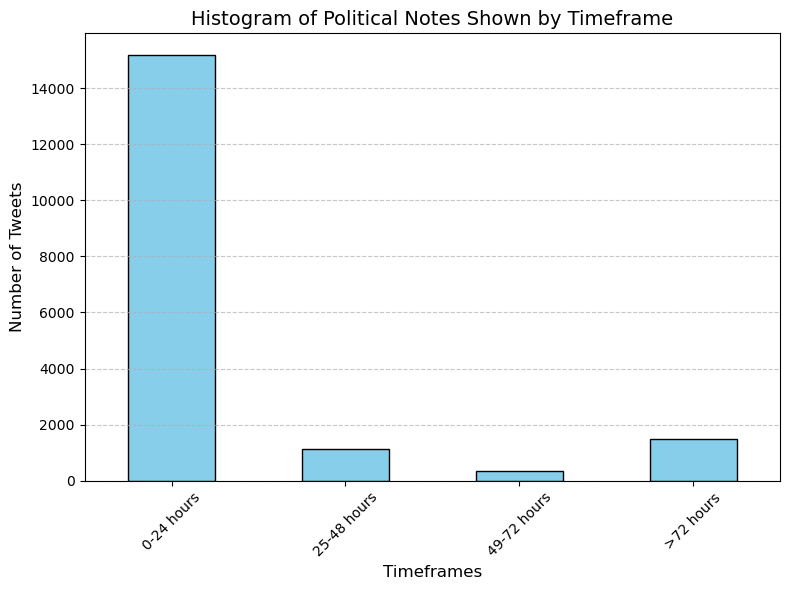

In [383]:
# Histogram of timeframes to get approved/posted:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for political notes that got shown
df_english = df[df['is_english'] == True]

filtered = tweet_level[(tweet_level['is_political'] == True) & (tweet_level['got_shown'] == 1)].copy()

# Create bins for timeframes
bins = [0, 24, 48, 72, float('inf')]  # Define bin edges
labels = ['0-24 hours', '25-48 hours', '49-72 hours', '>72 hours']  # Bin labels
filtered.loc[:, 'timeframe'] = pd.cut(filtered['hours_to_show'], bins=bins, labels=labels)

# Count notes in each timeframe
timeframe_counts = filtered['timeframe'].value_counts().sort_index()

# Plot histogram
plt.figure(figsize=(8, 6))
timeframe_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Histogram of Political Notes Shown by Timeframe', fontsize=14)
plt.xlabel('Timeframes', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

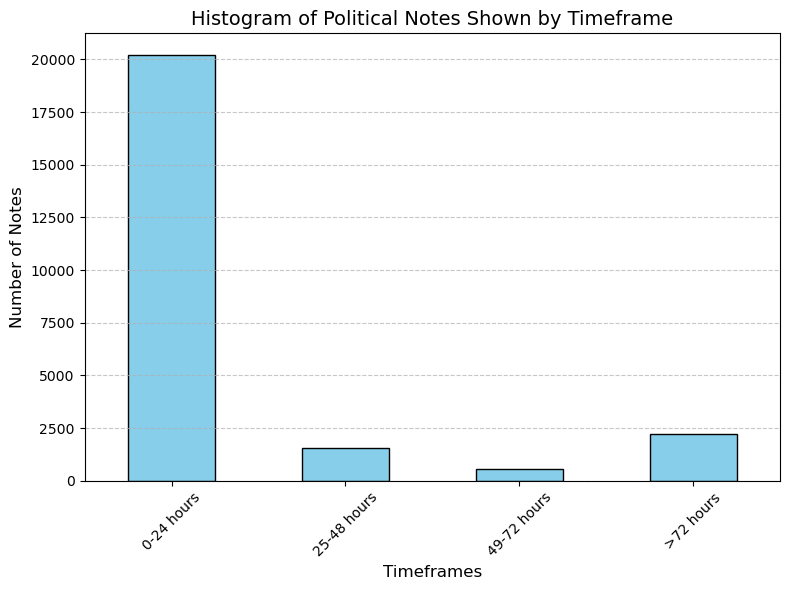

In [381]:
# Histogram of timeframes to get approved/posted:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for political notes that got shown
df_english = df[df['is_english'] == True]

filtered = df_english[(df_english['is_political'] == True) & (df_english['got_shown'] == 1)].copy()

# Create bins for timeframes
bins = [0, 24, 48, 72, float('inf')]  # Define bin edges
labels = ['0-24 hours', '25-48 hours', '49-72 hours', '>72 hours']  # Bin labels
filtered.loc[:, 'timeframe'] = pd.cut(filtered['hours_to_show'], bins=bins, labels=labels)

# Count notes in each timeframe
timeframe_counts = filtered['timeframe'].value_counts().sort_index()

# Plot histogram
plt.figure(figsize=(8, 6))
timeframe_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Histogram of Political Notes Shown by Timeframe', fontsize=14)
plt.xlabel('Timeframes', fontsize=12)
plt.ylabel('Number of Notes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Random samples for manual labeling

In [52]:
# Random sample of 10 tweets that got warnings and 10 that didn't (sample of OVERALL tweets)
tweet_level = df_english.groupby('tweetId').agg( 
    got_shown=('got_shown', 'max') 
)
tweet_warnings_rand = tweet_level[tweet_level['got_shown'] == 1].sample(frac=1, random_state=53).reset_index()
tweet_warnings_rand = tweet_warnings_rand.head(100)
tweet_warnings_rand.to_csv('tweet_warnings_rand.csv', index=False)

tweet_nowarnings_rand = tweet_level[tweet_level['got_shown'] == 0].sample(frac=1, random_state=53).reset_index()
tweet_nowarnings_rand = tweet_nowarnings_rand.head(100)
tweet_nowarnings_rand.to_csv('tweet_nowarnings_rand.csv', index=False)

In [541]:
#Function: tweet level, keyword-specific, random sample of 100 that got warnings and 100 that didn't

def keyword_rand(keyword):
    filtered = tweet_level[
        (tweet_level[f'is_{keyword}'] == True) &
        (tweet_level['got_shown'] == 1)
    ].sample(frac=1, random_state=44).reset_index()

    keyword_warning_rand = filtered.head(100)
    keyword_warning_rand.to_csv(f'{keyword}_warning_rand2.csv', index=False)

    filtered = tweet_level[
        (tweet_level[f'is_{keyword}'] == True) &
        (tweet_level['got_shown'] == 0)
    ].sample(frac=1, random_state=44).reset_index()

    keyword_nowarning_rand = filtered.head(100)
    keyword_nowarning_rand.to_csv(f'{keyword}_nowarning_rand2.csv', index=False)

    return #keyword_warning_rand, keyword_nowarning_rand

def keyword_rand_not_containing(keyword):
    filtered = tweet_level[
        (tweet_level[f'is_{keyword}'] == False) &
        (tweet_level['got_shown'] == 1)
    ].sample(frac=1, random_state=44).reset_index()

    keyword_warning_rand = filtered.head(100)
    keyword_warning_rand.to_csv(f'NOT {keyword}_warning_rand.csv', index=False)

    filtered = tweet_level[
        (tweet_level[f'is_{keyword}'] == False) &
        (tweet_level['got_shown'] == 0)
    ].sample(frac=1, random_state=44).reset_index()

    keyword_nowarning_rand = filtered.head(110)
    keyword_nowarning_rand.to_csv(f'NOT {keyword}_nowarning_rand.csv', index=False)

    return keyword_warning_rand, keyword_nowarning_rand

#keyword_rand('earthquakesmall')
keyword_rand_not_containing('political')

(     index              tweetId  is_political  is_trump  is_israel  is_covid  \
 0   432626  1829846905867694279         False     False      False     False   
 1   490433  1846971348142129348         False     False      False     False   
 2   147581  1729548117903568938         False     False      False     False   
 3    81163  1690272698117541889         False     False      False     False   
 4    49108  1655017600290791432         False     False      False     False   
 ..     ...                  ...           ...       ...        ...       ...   
 95  102351  1707389825169461621         False     False      False     False   
 96   84369  1692549892617773527         False     False      False     False   
 97   86017  1693622846461764018         False     False      False     False   
 98   25916  1593271354803032064         False     False      False     False   
 99   87370  1694457588786631044         False     False      False     False   
 
     is_earthquakesmall  g

# Note Submissions Count

In [772]:
df_english = df[df['is_english'] == True].copy()

In [774]:
# Create function that sums the # of notes for each is____ keyword list and puts into a dataframe:
submission_summary = []

def count_submissions(keyword):
    col = f'is_{keyword}'
    if col in df_english.columns:
        result = df_english.groupby(col)['noteId'].nunique()
        keyword_submission_count = result.loc[True] if True in result.index else 0
        submission_summary.append({'keyword': keyword, 'submission_count': keyword_submission_count})
    else:
        print(f"Column '{col}' not found.")

def count_submissions_not_containing(keyword):
    col = f'is_{keyword}'
    if col in df_english.columns:
        result = df_english.groupby(col)['noteId'].nunique()
        # Get count where is_{keyword} == False instead of True
        keyword_exclusion_count = result.loc[False] if False in result.index else 0
        submission_summary.append({'keyword': f'NOT {keyword}', 'submission_count': keyword_exclusion_count})
    else:
        print(f"Column '{col}' not found.")


In [784]:
# enter each keyword list name to call function (notes that DO NOT contain keywords):
count_submissions_not_containing('political253')

submission_count = pd.DataFrame(submission_summary)
submission_count.to_csv('submission_count.csv', index=False)

In [782]:
# enter each keyword list name to call function (notes that DO contain keywords):
count_submissions('political253')

submission_count = pd.DataFrame(submission_summary)
submission_count.to_csv('submission_count.csv', index=False)

In [85]:
# count total number of unique NoteIds (# of unique submissions)
df_english['noteId'].nunique()

910278

# Tweets Count

In [692]:
# Aggregate at the tweetId level (and english-only)
# Must adjust code to include needed columns

df_english = df[df['is_english'] == True]
tweet_level = df_english.groupby('tweetId').agg(
    is_political=('is_political', 'any'), 
    is_scam=('is_scam', 'any'),
    is_health=('is_health', 'any'),
    is_covid=('is_covid', 'any'),
    is_science=('is_science', 'any'),
    is_crypto=('is_crypto', 'any'),
    is_trump=('is_trump', 'any'),
    is_israel=('is_israel', 'any'),
    is_healthsciencecovid=('is_healthsciencecovid', 'any'),
    is_political75=('is_political75', 'any'),
    is_covid75=('is_covid75', 'any'),
    is_trump75=('is_trump75', 'any'),
    is_israel75=('is_israel75', 'any'),
    is_earthquake=('is_earthquake', 'any'),
    is_earthquakesmall=('is_earthquakesmall', 'any'),
    is_crypto75=('is_crypto75', 'any'),
    is_cancer=('is_cancer', 'any'),
    noteId=('noteId', lambda x: ','.join(map(str, x.unique())))
)

tweet_summary = []

def count_tweets(keyword):
    col = f'is_{keyword}'
    if col in tweet_level.columns:
        result = tweet_level.groupby(col)['noteId'].nunique()
        keyword_tweet_count = result.loc[True] if True in result.index else 0
        tweet_summary.append({'keyword': keyword, 'tweet_count': keyword_tweet_count})
    else:
        print(f"Column '{col}' not found.")

In [694]:
# enter each keyword list name to call function:
count_tweets('cancer')

tweet_count = pd.DataFrame(tweet_summary)
tweet_count.to_csv('tweet_count.csv', index=False)

In [133]:
# count total number of unique tweets (# of unique submissions)
df_english['tweetId'].nunique()

540415

In [344]:
# Create function that plots # of submissions for keyword or keyword list:

df_english = df[df['is_english']==True]

def plot_keywords_mixed(keywords_dict, search_col='summary'):
    collection_date = pd.Timestamp('2024-11-14')
    last_complete_week = collection_date - datetime.timedelta(days=collection_date.dayofweek + 1)

    # Ensure you're working on a fresh copy to avoid SettingWithCopyWarning
    df = df_english.copy()
    df['created_at'] = pd.to_datetime(df['createdAtMillis_x'], unit='ms')
    df_complete = df[df['created_at'] <= last_complete_week]

    plt.figure(figsize=(20, 10))

    weekly_all = df_complete.set_index('created_at').resample('W').size()
    plt.plot(weekly_all.index, weekly_all.values, lw=2.5, linestyle='--', marker='o',
             label='All Notes', alpha=0.6)

    for keyword, mode in keywords_dict.items():
        if mode == 'column':
            mask = df.get(f'is_{keyword}', pd.Series(False, index=df.index))
        elif mode == 'search':
            mask = df[search_col].str.contains(fr'\b{keyword}\b', case=False, na=False, regex=True)
        else:
            raise ValueError(f"Unknown mode '{mode}' for keyword '{keyword}' (use 'column' or 'search')")

        keyword_notes = df[mask & (df['created_at'] <= last_complete_week)].copy()
        weekly_keyword = keyword_notes.set_index('created_at').resample('W').size()

        plt.plot(weekly_keyword.index, weekly_keyword.values, lw=2.5, marker='o',
                 label=f'{keyword} ({mode})')

    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axvline(x=last_complete_week, color='r', linestyle='--', alpha=0.7)
    plt.text(last_complete_week - datetime.timedelta(days=15), plt.ylim()[1]*0.9, 
             'Data collected on Nov 14, 2024', 
             rotation=90, verticalalignment='top', color='red')

    plt.title('Community Notes Submissions', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Submissions', fontsize=12)
    plt.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

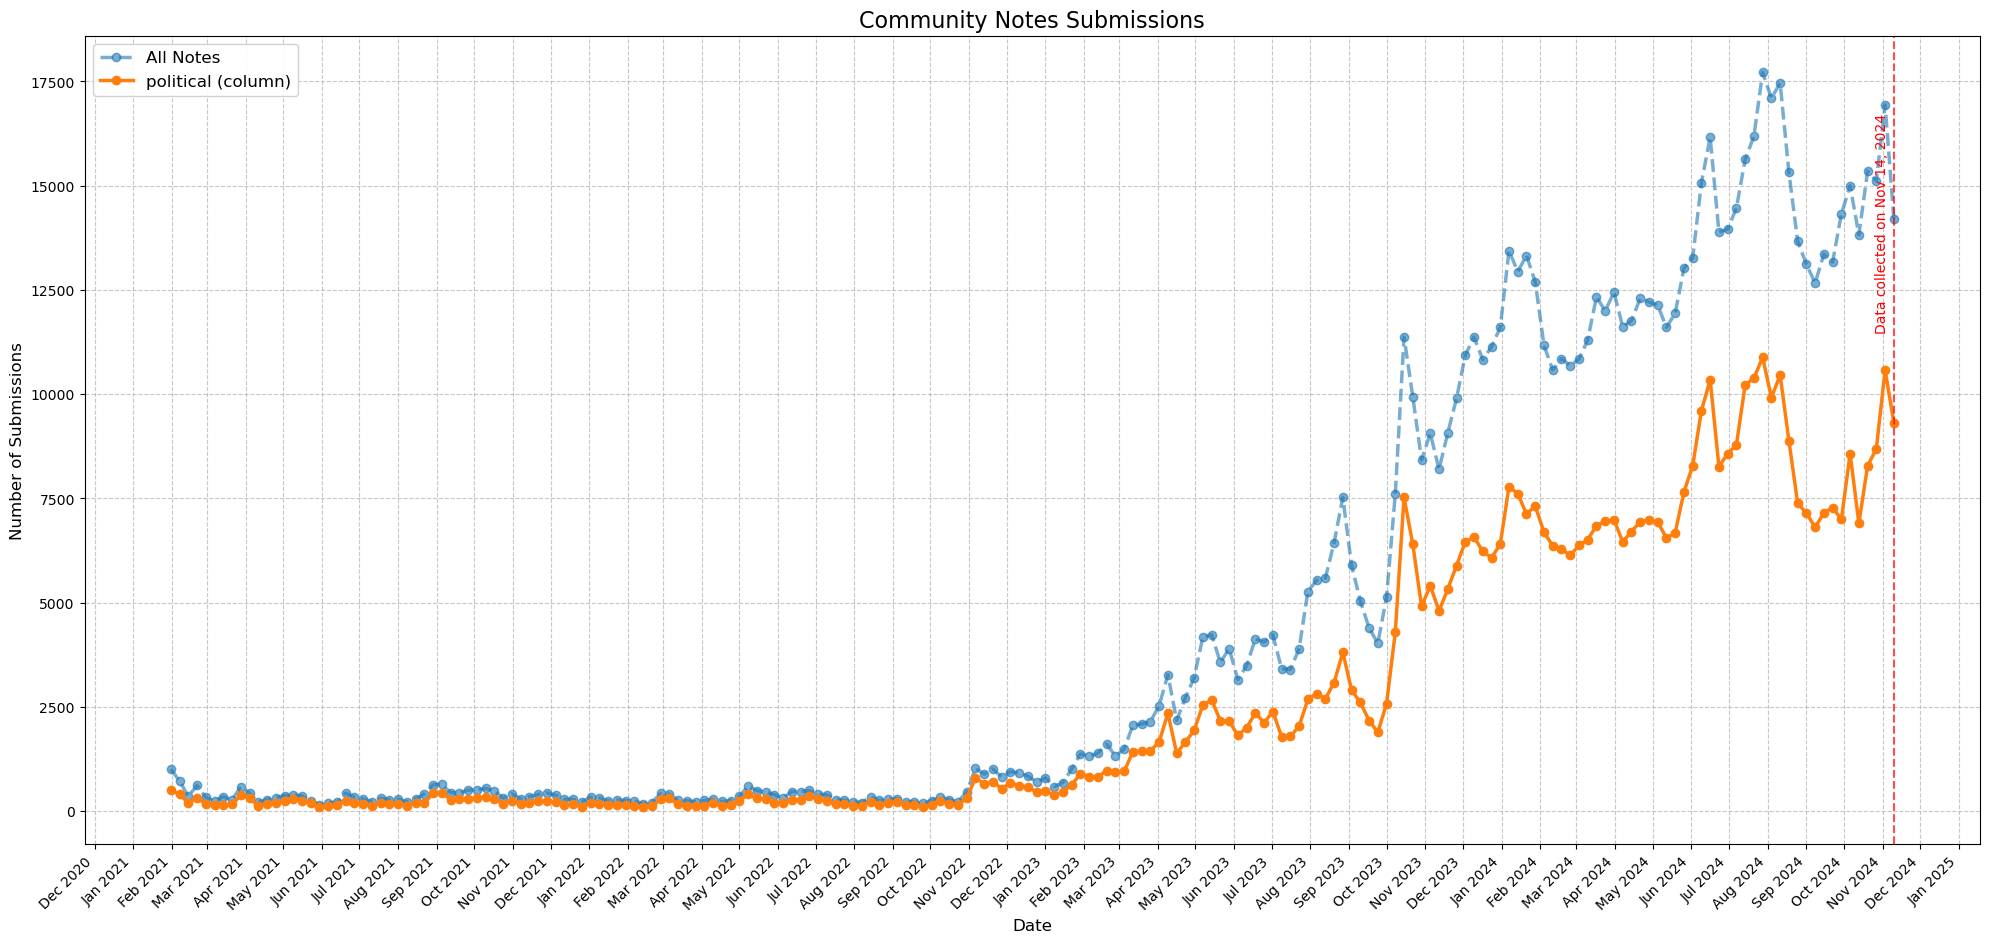

In [345]:
plot_keywords_mixed({
    'political': 'column',
    
})

# Ratings Count

In [3]:
# preprocessing ratings to use in the next cell

all_ratings = pd.read_csv("all_ratings.csv", usecols=['noteId'])
ratings_count = all_ratings['noteId'].value_counts().reset_index()
ratings_count.columns = ['noteId', 'rating_count']

In [70]:
df_english = df_english.merge(ratings_count, on='noteId', how='left')
len(df_english)

668683

In [74]:
df_english[df_english['is_earthquakesmall']]['rating_count'].sum()


116055.0

In [9]:
# How many ratings per note in descending order (for notes with less than 5 ratings)
df_filtered = df_english[(df_english['rating_count'] < 5) | (df_english['rating_count'].isna())]
df_filtered_sorted = df_filtered.sort_values(by='rating_count', ascending=True)
df_filtered_sorted.to_csv('df_english_sorted.csv', index=False)
len(df_filtered_sorted)

171372

In [17]:
# total % of notes that received <5 ratings overall:
(len(df_filtered)/len(df_english))

0.2562828724522681

In [607]:
# Calculate % of notes that receive <5 ratings for a given subtopic:
def percent_under5_ratings(keyword):
    df_filtered = df_english[(df_english[f'{keyword}'] == True) & ((df_english['rating_count'] < 5) | (df_english['rating_count'].isna()))]
    length_keyword_under5 = len(df_filtered)
    length_keyword = (df_english[f'{keyword}'] == True).sum()
    percent_keyword = length_keyword_under5/length_keyword
    print(percent_keyword)

In [617]:
percent_under5_ratings('is_cancer')

0.1769483324693278


In [78]:
# functions to calculate median # of ratings for each topic
rating_summary = []

def count_ratings(keyword):
    col = f'is_{keyword}'
    if col in df_english.columns:
        result = df_english.groupby(col)['rating_count'].median()
        keyword_rating_count = result.loc[True] if True in result.index else 0
        rating_summary.append({'keyword': keyword, 'rating_count': keyword_rating_count})
    else:
        print(f"Column '{col}' not found.")

def count_ratings_not_containing(keyword):
    col = f'is_{keyword}'
    if col in df_english.columns:
        result = df_english.groupby(col)['rating_count'].median()
        keyword_rating_count = result.loc[False] if False in result.index else 0
        rating_summary.append({'keyword': f'NOT {keyword}', 'rating_count': keyword_rating_count})
    else:
        print(f"Column '{col}' not found.")

count_ratings('earthquakesmall')

#count_ratings_not_containing('political')

print(rating_summary)

[{'keyword': 'earthquakesmall', 'rating_count': 8.0}]


In [577]:
# calculate median # of ratings overall
df_english['rating_count'].median()

29.0

In [666]:
# Functions to calculate the sum the # of ratings for each topic:
rating_summary = []

def count_ratings(keyword):
    col = f'is_{keyword}'
    if col in df_english.columns:
        result = df_english.groupby(col)['rating_count'].sum()
        keyword_rating_count = result.loc[True] if True in result.index else 0
        rating_summary.append({'keyword': keyword, 'rating_count': keyword_rating_count})
    else:
        print(f"Column '{col}' not found.")

def count_ratings_not_containing(keyword):
    col = f'is_{keyword}'
    if col in df_english.columns:
        result = df_english.groupby(col)['rating_count'].sum()
        keyword_rating_count = result.loc[False] if False in result.index else 0
        rating_summary.append({'keyword': f'NOT {keyword}', 'rating_count': keyword_rating_count})
    else:
        print(f"Column '{col}' not found.")

In [69]:
df_english['rating_count'].sum()

73365225.0

In [211]:
# creates a function that plots # of ratings for given keywords:

def plot_filtered_note_counts(df, ratings_count, keywords_dict, search_col='summary'):
    collection_date = pd.Timestamp('2024-11-14')
    last_complete_week = collection_date - datetime.timedelta(days=collection_date.dayofweek + 1)

    df_english = df[df['is_english'] == True].copy()
    df_english['created_at'] = pd.to_datetime(df_english['createdAtMillis_x'], unit='ms')
    df_english = df_english[df_english['created_at'] <= last_complete_week]

    df_english = df_english.merge(ratings_count, on='noteId', how='left')
    df_english['rating_count'] = df_english['rating_count'].fillna(0).astype(int)

    plt.figure(figsize=(20, 10))
    weekly_all = df_english.resample('W', on='created_at')['rating_count'].sum()
    plt.plot(weekly_all.index, weekly_all.values, lw=2.5, linestyle='--', marker='o',
             label='All Notes', alpha=0.6)

    for keyword, mode in keywords_dict.items():
        if mode == 'column':
            mask = df_english.get(f'is_{keyword}', pd.Series(False, index=df_english.index))

        elif mode == 'search':
            mask = df_english[search_col].str.contains(fr'\b{keyword}\b', case=False, na=False, regex=True)

        elif mode == 'custom':
            if keyword == 'non_political':
                mask = ~df_english.get('is_political', pd.Series(False, index=df_english.index))
            else:
                raise ValueError(f"Custom mode not implemented for keyword '{keyword}'")

        else:
            raise ValueError(f"Unknown mode '{mode}' for keyword '{keyword}' (use 'column', 'search', or 'custom')")

        keyword_df = df_english[mask].copy()
        weekly_ratings = keyword_df.resample('W', on='created_at')['rating_count'].sum()

        plt.plot(weekly_ratings.index, weekly_ratings.values, lw=2.5, marker='o',
                 label=f'{keyword} ({mode})')

    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axvline(x=last_complete_week, color='r', linestyle='--', alpha=0.7)
    plt.text(last_complete_week - datetime.timedelta(days=15), plt.ylim()[1]*0.9, 
             'Data collected on Nov 14, 2024', 
             rotation=90, verticalalignment='top', color='red')
    plt.title('Community Notes Ratings', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Ratings', fontsize=12)
    plt.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

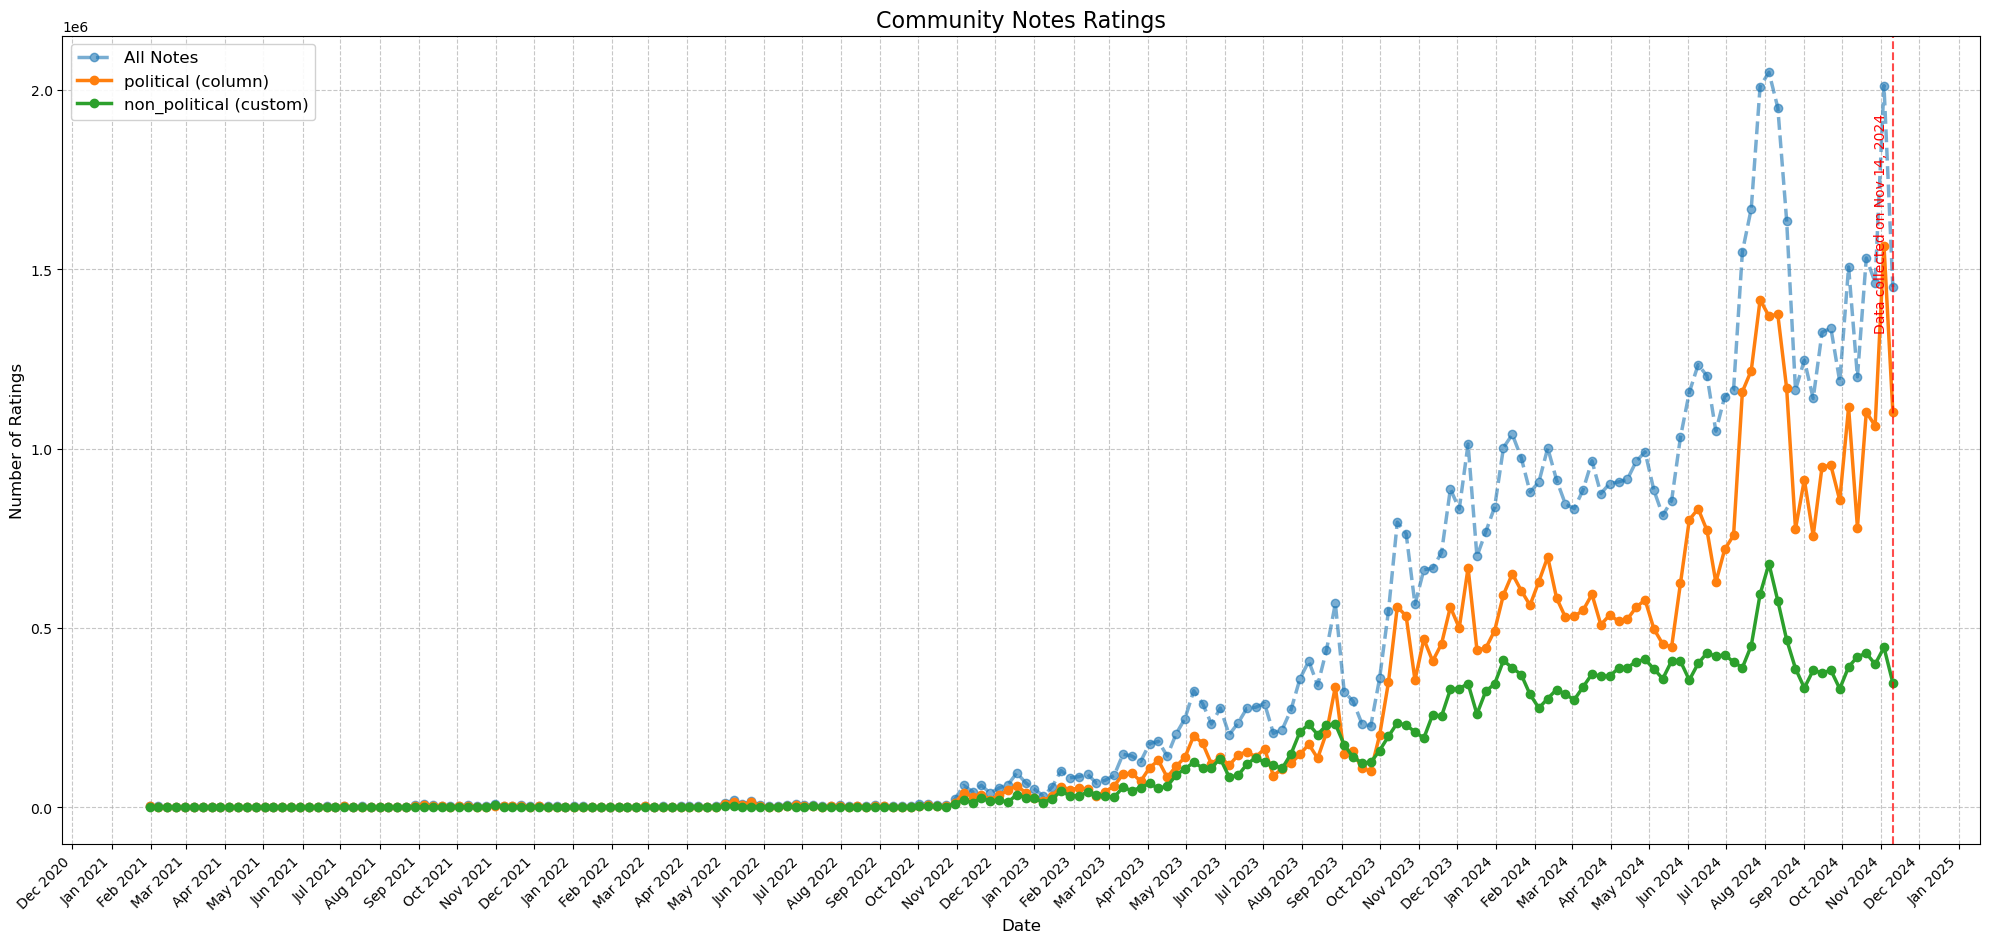

In [213]:
keywords_dict = {
    'political': 'column',
    'non_political': 'custom'
}

plot_filtered_note_counts(df, ratings_count, keywords_dict)

# Statistical Analysis

In [58]:
# calculating correlation coefficient for recall and ratings <5:
df_correlation = pd.read_csv('Findings - CorrelationData.csv')
df_correlation['Recall'] = df_correlation['Recall'].str.replace('%', '').astype(float)
df_correlation['% <5 ratings'] = df_correlation['% <5 ratings'].str.replace('%', '').astype(float)
correlation = df_correlation['Recall'].corr(df_correlation['% <5 ratings'])
print(correlation)

-0.5063318980983748


In [56]:
# calculate correlation between recall and rating medians:
df_correlation = pd.read_csv('Findings - CorrelationData.csv')
df_correlation['Recall'] = df_correlation['Recall'].str.replace('%', '').astype(float)
df_correlation['Engagement'] = df_correlation['Engagement']
correlation = df_correlation['Recall'].corr(df_correlation['Engagement'])
print(correlation)

0.5147382580523188


In [60]:
# calculate correlation between Percent >Helpful and Recall:
df_correlation = pd.read_csv('Findings - CorrelationData.csv')
df_correlation['Recall'] = df_correlation['Recall'].str.replace('%', '').astype(float)
df_correlation['Percent >Helpful'] = df_correlation['Percent >Helpful'].str.replace('%', '').astype(float)
correlation = df_correlation['Recall'].corr(df_correlation['Engagement'])
print(correlation)

0.5147382580523188


In [62]:
# calculate correlation between Percent <5 ratings and engagement median:
df_correlation = pd.read_csv('Findings - CorrelationData.csv')
df_correlation['% <5 ratings'] = df_correlation['% <5 ratings'].str.replace('%', '').astype(float)
correlation = df_correlation['Engagement'].corr(df_correlation['% <5 ratings'])
print(correlation)

-0.7803435765893199


# Views

In [ ]:
# comparing median views for False vs True posts:
# Want to see how # of views impacts false negatives

sample_df = pd.read_csv('cancer_nowarning_rand.csv')

def median_views_by_truth(sample_df):
    sample_df = sample_df.copy()
    sample_df['views'] = sample_df['views'].astype(str).str.replace(',', '').str.strip()
    sample_df['views'] = pd.to_numeric(sample_df['views'], errors='coerce')

    sample_df['truth_clean'] = sample_df['true?'].astype(str).str.strip().str.upper()
    
    truthy_values = ['TRUE', 'OPINION']
    falsey_value = 'FALSE'
    
    true_median = sample_df[sample_df['truth_clean'].isin(truthy_values)]['views'].median()
    false_median = sample_df[sample_df['truth_clean'] == falsey_value]['views'].median()
    
    return {
        'TRUE_OR_OPINION': true_median,
        'FALSE': false_median
    }

In [ ]:
median_views_by_truth(sample_df)

In [ ]:
# calculate combined (nowarning and warning) median views for each topic category:

def combined_median_views(topic):
    df_nowarning = pd.read_csv(f'{topic}_nowarning_rand.csv')
    df_warning = pd.read_csv(f'{topic}_warning_rand.csv')

    for df in [df_nowarning, df_warning]:
        df['views'] = df['views'].astype(str).str.replace(',', '').str.strip()
        df['views'] = pd.to_numeric(df['views'], errors='coerce')

    combined_views = pd.concat([df_nowarning['views'], df_warning['views']])

    return combined_views.median()

In [ ]:
combined_median_views('earthquakesmall')

# Gauge impact of ideological consensus -  Sum Helpful vs notHelpful ratings

In [19]:
all_ratings = pd.read_csv("all_ratings.csv")

columns_to_keep = [
    "noteId",
    "ratedOnTweetId",
    "helpfulOther",
    "helpfulClear",
    "helpfulGoodSources",
    "helpfulAddressesClaim",
    "helpfulImportantContext",
    "helpfulUnbiasedLanguage",
    "notHelpfulOther",
    "notHelpfulIncorrect",
    "notHelpfulSourcesMissingOrUnreliable",
    "notHelpfulMissingKeyPoints",
    "notHelpfulHardToUnderstand",
    "notHelpfulArgumentativeOrBiased",
    "notHelpfulSpamHarassmentOrAbuse",
    "notHelpfulIrrelevantSources",
    "notHelpfulOpinionSpeculation",
    "notHelpfulNoteNotNeeded"
]

ratings_filtered = all_ratings[columns_to_keep]

In [21]:
# Find sum for Helpful and notHelpful columns for each tweetId
ratings_aggregated = ratings_filtered.groupby("ratedOnTweetId", as_index=False).sum()

helpful_cols = [col for col in ratings_aggregated.columns if col.startswith("helpful")]
not_helpful_cols = [col for col in ratings_aggregated.columns if col.startswith("notHelpful")]

ratings_summary = ratings_aggregated[["ratedOnTweetId"]].copy()
ratings_summary["helpful_total"] = ratings_aggregated[helpful_cols].sum(axis=1)
ratings_summary["notHelpful_total"] = ratings_aggregated[not_helpful_cols].sum(axis=1)

In [411]:
# Function to count percent of time notes for unflagged tweets received more Helpful ratings than notHelpful (from random samples)
# To find examples for report
# (must change "100" at the bottom to how ever many samples are in the file)

def more_helpful_ratings(keyword, ratings_summary):
    df = pd.read_csv(f"{keyword}_nowarning_rand2.csv", dtype={"tweetId": str})
    
    ratings_summary["ratedOnTweetId"] = ratings_summary["ratedOnTweetId"].astype(str)
    
    merged_df = df.merge(
        ratings_summary, 
        left_on="tweetId", 
        right_on="ratedOnTweetId", 
        how="left"
    ).drop(columns=["ratedOnTweetId"])
    
    merged_df.to_csv(f"{keyword}_nowarning_rand_scores2.csv", index=False)
    
    count = (merged_df["helpful_total"] > merged_df["notHelpful_total"]).sum() / 100
    print(count)

more_helpful_ratings('earthquakesmall', ratings_summary)

0.33


In [43]:
# Function to count percent of time notes for unflagged tweets received more Helpful ratings than notHelpful
# Full datasets, not just random samples

def more_helpful_ratings_full(keyword, ratings_summary):
    df = tweet_level[(tweet_level[f'is_{keyword}']==True) & (tweet_level["got_shown"] == 0)].copy()
    total = len(df)

    df["tweetId"] = df["tweetId"].astype(str)
    ratings_summary["ratedOnTweetId"] = ratings_summary["ratedOnTweetId"].astype(str)
    
    merged_df = df.merge(
        ratings_summary, 
        left_on="tweetId", 
        right_on="ratedOnTweetId", 
        how="left"
    ).drop(columns=["ratedOnTweetId"])
    
    count = (merged_df["helpful_total"] > merged_df["notHelpful_total"]).sum() / total
    print(count)

more_helpful_ratings_full('cancer', ratings_summary)

0.5974745919310133


In [ ]:
# calculate overall percent Helpful>notHelpful

df = tweet_level[tweet_level['got_shown'] == 0].copy()
total = len(df)

df["tweetId"] = df["tweetId"].astype(str)
ratings_summary["ratedOnTweetId"] = ratings_summary["ratedOnTweetId"].astype(str)
    
merged_df = df.merge(
ratings_summary, 
left_on="tweetId", 
right_on="ratedOnTweetId", 
how="left"
).drop(columns=["ratedOnTweetId"])
    
count = (merged_df["helpful_total"] > merged_df["notHelpful_total"]).sum() / total

In [46]:
print(count)

0.5298176452699278
